In [1]:
import numpy as np

In [2]:
import pandas as pd

In [4]:
image = np.array([
    [0, 50, 100],
    [150, 200, 250],
    [255, 128, 64]
])


In [5]:
print(image)
print("Shape: ", image.shape)
print("Data type: ", image.dtype)
print("Max value: ", np.max(image))
print("Min value: ", np.min(image))

[[  0  50 100]
 [150 200 250]
 [255 128  64]]
Shape:  (3, 3)
Data type:  int64
Max value:  255
Min value:  0


In [6]:
print(image[0,1])
image[1,1] = 250
print(image)
print("#####################################")
image[0] = [77, 75, 90]
print(image)
print("#####################################")
image[:,2] = [1,2,3]
print(image)
print("#####################################")
print("Max value: ", np.max(image))
print("Min value: ", np.min(image))
print("#####################################")

50
[[  0  50 100]
 [150 250 250]
 [255 128  64]]
#####################################
[[ 77  75  90]
 [150 250 250]
 [255 128  64]]
#####################################
[[ 77  75   1]
 [150 250   2]
 [255 128   3]]
#####################################
Max value:  255
Min value:  1
#####################################


In [7]:
import matplotlib.pyplot as plt
import numpy as np

In [8]:
image = np.zeros((400, 400), dtype=np.uint8)

In [9]:
image[100:300, 100:300] = 255

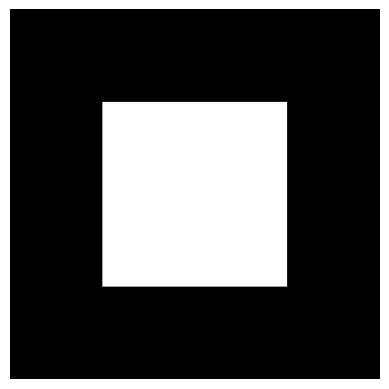

In [12]:
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.show()

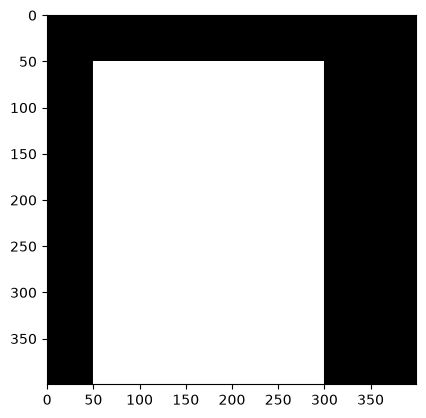

In [62]:
image = np.zeros((400, 400), dtype=np.uint8)
image[50:3000, 50:300] = 255
plt.imshow(image, cmap='gray')
# plt.axis('off')
plt.show()

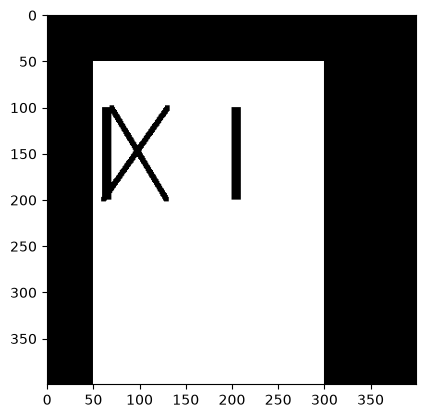

In [63]:
image[100:200, 60:70] = 0
image[100:200, 200:210] = 0

# diagonal lines
for i in range(100):
    # left diagonal: (100, 70) -> (150, 130)
    x = 100 + i
    y = 70 + int(i * 0.6)
    image[x-2:x+3, y-2:y+3] = 0

    # right diagonal: (100, 130) -> (200, 70)
    y2 = 130 - int(i * 0.7)
    image[x-2:x+3, y2-2:y2+3] = 0

plt.imshow(image, cmap='gray')
plt.show()

In [11]:
import PIL.Image as Image

In [ ]:
img = Image.open("")

In [48]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt


In [64]:
path = "image.jpg"
img = Image.open(path)
image = np.array(img)


Shape: (737, 415, 3)
Data type: uint8
Minimum: 0
Maximum: 255
Mean: 142.42962950853618


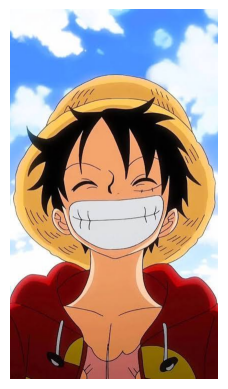

In [65]:
print("Shape:", image.shape)
print("Data type:", image.dtype)
print("Minimum:", image.min())
print("Maximum:", image.max())
print("Mean:", image.mean())

plt.imshow(image, cmap="gray")
plt.axis("off")
plt.show()


In [66]:
print("RGB shape:", image.shape)
print("RGB dtype:", image.dtype)

RGB shape: (737, 415, 3)
RGB dtype: uint8


Gray shape: (737, 415)


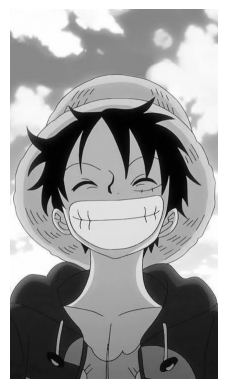

In [74]:
gray = np.array(Image.open(path).convert("L"))
print("Gray shape:", gray.shape)
plt.imshow(gray,cmap="gray")
plt.axis("off")
plt.show()

In [78]:
import cv2 as cv

In [ ]:
image = cv.imread(path)

hsv = cv.cvtColor(image, cv.COLOR_BGR2HSV)

plt.imshow(cv.cvtColor(hsv, cv.COLOR_HSV2RGB))

print("HSV shape:", hsv.shape)
print("H:", hsv[:, :, 0].min(), hsv[:, :, 0].max())
print("S:", hsv[:, :, 1].min(), hsv[:, :, 1].max())
print("V:", hsv[:, :, 2].min(), hsv[:, :, 2].max())

HSV shape: (737, 415, 3)
H: 0 179
S: 0 255
V: 0 255


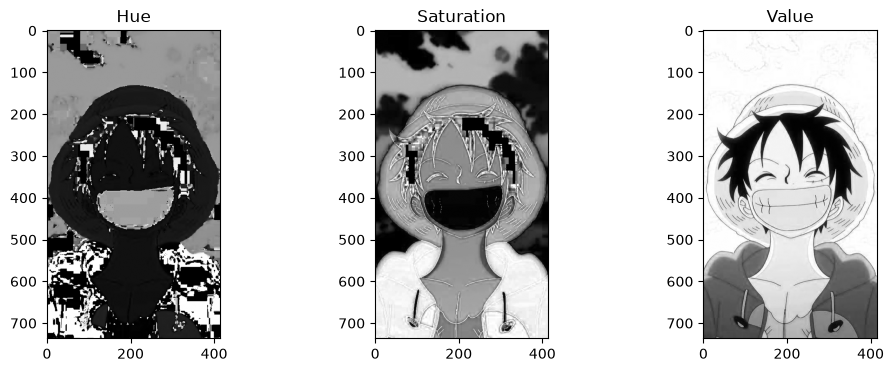

In [81]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(hsv[:, :, 0], cmap="gray")
plt.title("Hue")

plt.subplot(1, 3, 2)
plt.imshow(hsv[:, :, 1], cmap="gray")
plt.title("Saturation")

plt.subplot(1, 3, 3)
plt.imshow(hsv[:, :, 2], cmap="gray")
plt.title("Value")

plt.show()

Histogram shape: (256,)
Total pixels: 305855


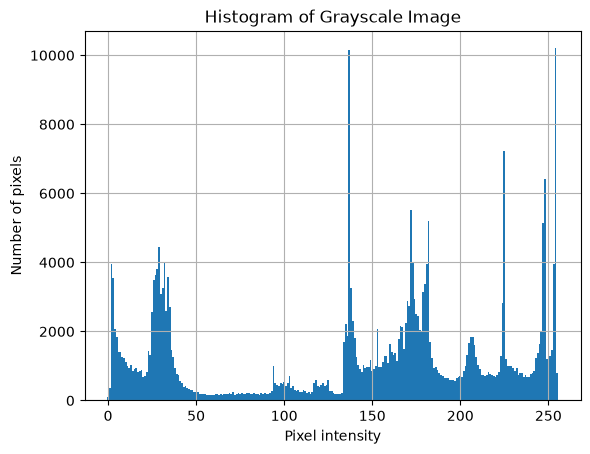

In [84]:
image = np.array(Image.open(path).convert("L"))

histogram = np.bincount(image.ravel(), minlength=256)

print("Histogram shape:", histogram.shape)
print("Total pixels:", histogram.sum()) 

plt.bar(
    range(256),
    histogram,
    width=1
)
plt.xlabel("Pixel intensity")
plt.ylabel("Number of pixels")
plt.title("Histogram of Grayscale Image")
plt.grid(True)
plt.show()

In [85]:
cdf = histogram.cumsum()

cdf_min = cdf[cdf > 0][0]  # Get the first non-zero value of the CDF
N = image.size

mapping = ((cdf -cdf_min) / (N - cdf_min) * 255)
mapping = np.clip(mapping, 0, 255).astype(np.uint8)

equalized = mapping[image]

In [86]:
print(image.shape)
print(equalized.shape)

(737, 415)
(737, 415)


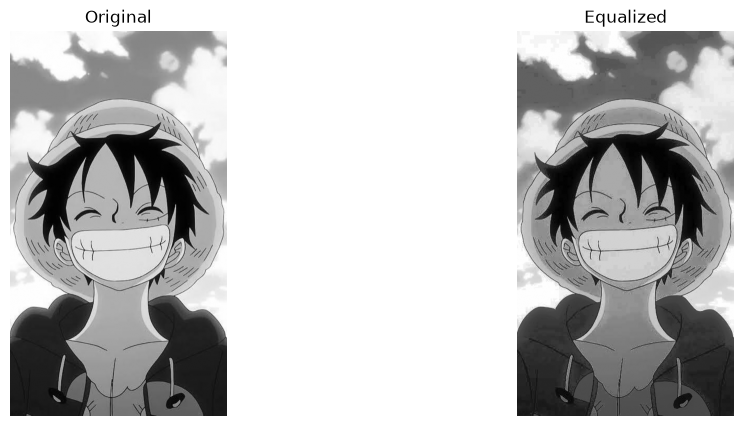

In [87]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(equalized, cmap="gray")
plt.title("Equalized")
plt.axis("off")

plt.show()

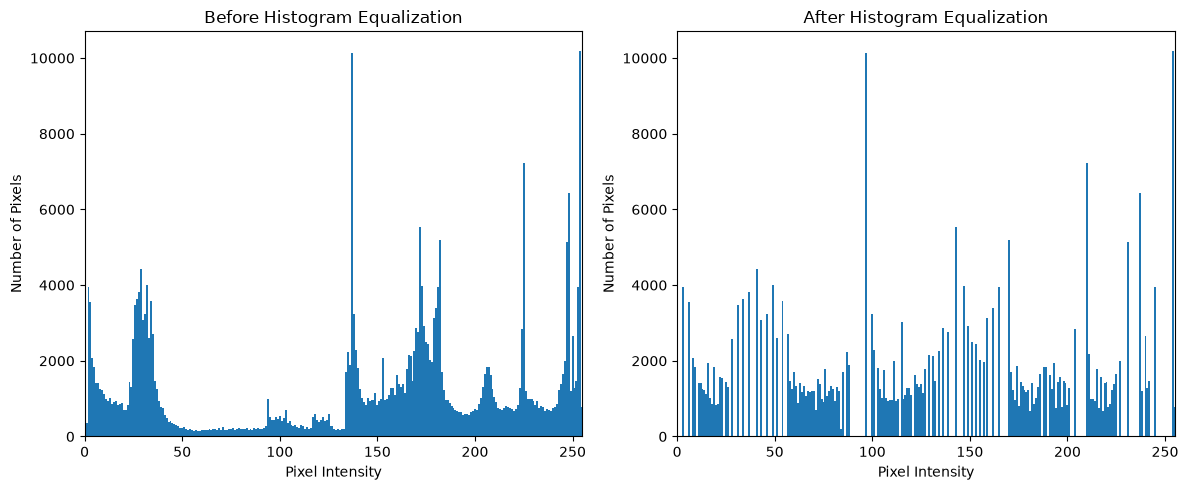

In [88]:
# Original histogram
hist_original = np.bincount(
    image.ravel(),
    minlength=256
)

# Equalized histogram
hist_equalized = np.bincount(
    equalized.ravel(),
    minlength=256
)

# Plot both
plt.figure(figsize=(12, 5))

# Before
plt.subplot(1, 2, 1)
plt.bar(range(256), hist_original, width=1)
plt.title("Before Histogram Equalization")
plt.xlabel("Pixel Intensity")
plt.ylabel("Number of Pixels")
plt.xlim(0, 255)

# After
plt.subplot(1, 2, 2)
plt.bar(range(256), hist_equalized, width=1)
plt.title("After Histogram Equalization")
plt.xlabel("Pixel Intensity")
plt.ylabel("Number of Pixels")
plt.xlim(0, 255)

plt.tight_layout()
plt.show()